<h3>Effects of Grain Size and Nose Radius on the Machining Behaviour of Nimonic 263 Alloy During End Milling</h3>

<small>This notebook presents a machining-focused research study on how grain size and nose radius influence the machining behaviour of Nimonic 263 during end milling. A machine-learning-based predictive model is used to estimate machining responses, with emphasis on cutting forces (`RF1`, `RF2`) and temperature.</small>

<h5>Data Loading</h5>

<small>The dataset, libraries, and working paths used for the machining study are loaded in this section.</small>

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "machining_data.xlsx"
MODEL_PATH = PROJECT_ROOT / "models" / "random_forest_model.pkl"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "model_metrics.json"
PLOTS_DIR = PROJECT_ROOT / "outputs" / "plots"
BATCH_INPUT_PATH = PROJECT_ROOT / "prediction_inputs.xlsx"
BATCH_OUTPUT_PATH = PROJECT_ROOT / "predictions.xlsx"

for path in [MODEL_PATH.parent, METRICS_PATH.parent, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["rake_angle", "nose_radius", "grain_size", "cutting_speed"]
TARGET_COLUMNS = ["RF1", "RF2", "temperature"]
CATEGORICAL_COLUMNS = ["rake_angle", "grain_size"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {RAW_DATA_PATH}")

Project root: c:\Users\greyy\Documents\nimonic_ai
Dataset path: c:\Users\greyy\Documents\nimonic_ai\data\machining_data.xlsx


In [2]:
df_raw = pd.read_excel(RAW_DATA_PATH)
required_columns = FEATURE_COLUMNS + TARGET_COLUMNS
missing_columns = [column for column in required_columns if column not in df_raw.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

df_raw = df_raw[required_columns].copy()
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())

Dataset shape: (9, 7)


,rake_angle,nose_radius,grain_size,cutting_speed,RF1,RF2,temperature
0,5,0.2,fine,0.5,2.0,-2.5,330
1,5,0.4,medium,0.5,1.7,-2.2,312
2,5,0.2,coarse,0.5,1.5,-2.0,265
3,-5,0.6,fine,0.5,2.4,-2.9,355
4,-5,0.9,coarse,0.5,1.8,-2.3,285


<h5>Dataset Exploration</h5>

<small>This section summarizes the dataset structure, missing values, variable types, and the available machining conditions.</small>

In [3]:
print("Missing values by column:")
display(df_raw.isna().sum().rename("missing_values").to_frame())

print("Column data types:")
display(df_raw.dtypes.rename("dtype").to_frame())

print("Descriptive statistics for numeric columns:")
display(df_raw.describe(include=[np.number]).T)

print("Observed categorical levels:")
for column in CATEGORICAL_COLUMNS:
    print(f"- {column}: {sorted(df_raw[column].astype(str).unique().tolist())}")

Missing values by column:


,missing_values
rake_angle,0
nose_radius,0
grain_size,0
cutting_speed,0
RF1,0
RF2,0
temperature,0


Column data types:


,dtype
rake_angle,int64
nose_radius,float64
grain_size,str
cutting_speed,float64
RF1,float64
RF2,float64
temperature,int64


Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
rake_angle,9.0,1.111111,4.859127,-5.0,-5.0,5.0,5.0,5.0
nose_radius,9.0,0.466667,0.312250,0.0,0.2,0.4,0.6,0.9
cutting_speed,9.0,0.500000,0.000000,0.5,0.5,0.5,0.5,0.5
RF1,9.0,1.944444,0.260342,1.5,1.8,2.0,2.1,2.4
RF2,9.0,-2.455556,0.269774,-2.9,-2.6,-2.5,-2.3,-2.0
temperature,9.0,312.888889,33.258249,265.0,285.0,325.0,338.0,355.0


Observed categorical levels:
- rake_angle: ['-5', '0', '5']
- grain_size: ['coarse', 'fine', 'medium']


<h5>Data Preprocessing</h5>

<small>The input variables are prepared for analysis by cleaning the dataset and encoding the categorical machining factors.</small>

In [4]:
df_clean = df_raw.dropna().copy()
for column in CATEGORICAL_COLUMNS:
    df_clean[column] = df_clean[column].astype(str)

X_raw = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMNS].copy()
X_encoded = pd.get_dummies(X_raw, columns=CATEGORICAL_COLUMNS, dtype=float)
feature_names = X_encoded.columns.tolist()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Encoded feature matrix shape: {X_encoded.shape}")
display(X_encoded.head())

Clean dataset shape: (9, 7)
Encoded feature matrix shape: (9, 8)


,nose_radius,cutting_speed,rake_angle_-5,rake_angle_0,rake_angle_5,grain_size_coarse,grain_size_fine,grain_size_medium
0,0.2,0.5,0.0,0.0,1.0,0.0,1.0,0.0
1,0.4,0.5,0.0,0.0,1.0,0.0,0.0,1.0
2,0.2,0.5,0.0,0.0,1.0,1.0,0.0,0.0
3,0.6,0.5,1.0,0.0,0.0,0.0,1.0,0.0
4,0.9,0.5,1.0,0.0,0.0,1.0,0.0,0.0


<h5>Train-Test Split</h5>

<small>The dataset is divided into training and testing subsets using a 75%/25% split so the training data and testing data are clearly visible for academic presentation.</small>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
)

train_dataset = df_clean.loc[X_train.index, FEATURE_COLUMNS + TARGET_COLUMNS].copy()
test_dataset = df_clean.loc[X_test.index, FEATURE_COLUMNS + TARGET_COLUMNS].copy()

print(f"Training Dataset Shape: {train_dataset.shape}")
print(f"Testing Dataset Shape: {test_dataset.shape}")
print(f"Training Feature Matrix Shape: {X_train.shape}")
print(f"Testing Feature Matrix Shape: {X_test.shape}")
print(f"Training Sample Count: {len(train_dataset)}")
print(f"Testing Sample Count: {len(test_dataset)}")

print("Training dataset examples:")
display(train_dataset.reset_index(drop=True))
print("Testing dataset examples:")
display(test_dataset.reset_index(drop=True))

Training Dataset Shape: (6, 7)
Testing Dataset Shape: (3, 7)
Training Feature Matrix Shape: (6, 8)
Testing Feature Matrix Shape: (3, 8)
Training Sample Count: 6
Testing Sample Count: 3
Training dataset examples:


,rake_angle,nose_radius,grain_size,cutting_speed,RF1,RF2,temperature
0,5,0.2,fine,0.5,2.0,-2.5,330
1,0,0.0,medium,0.5,2.1,-2.6,266
2,5,0.2,coarse,0.5,1.5,-2.0,265
3,-5,0.9,coarse,0.5,1.8,-2.3,285
4,-5,0.6,fine,0.5,2.4,-2.9,355
5,-5,0.4,fine,0.5,2.1,-2.7,340


Testing dataset examples:


,rake_angle,nose_radius,grain_size,cutting_speed,RF1,RF2,temperature
0,5,0.9,medium,0.5,2.0,-2.5,338
1,5,0.4,medium,0.5,1.7,-2.2,312
2,5,0.6,medium,0.5,1.9,-2.4,325


<h5>LOOCV Validation</h5>

<small>Leave-One-Out Cross Validation (LOOCV) is applied on the training data to assess predictive consistency for this small machining dataset.</small>

In [6]:
def evaluate_predictions(y_true, y_pred, target_names):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    metrics = {}
    for index, target in enumerate(target_names):
        actual = y_true_array[:, index]
        predicted = y_pred_array[:, index]
        metrics[target] = {
            "mae": float(mean_absolute_error(actual, predicted)),
            "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
            "r2": float(r2_score(actual, predicted)),
        }
    metrics["average"] = {
        "mae": float(mean_absolute_error(y_true_array, y_pred_array)),
        "rmse": float(np.sqrt(mean_squared_error(y_true_array, y_pred_array))),
        "r2": float(r2_score(y_true_array, y_pred_array, multioutput="uniform_average")),
    }
    return metrics

base_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

loo = LeaveOneOut()
loocv_predictions = []
loocv_truth = []

for train_index, valid_index in loo.split(X_train):
    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[valid_index]
    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[valid_index]

    fold_model = clone(base_model)
    fold_model.fit(X_fold_train, y_fold_train)
    loocv_predictions.append(fold_model.predict(X_fold_valid)[0])
    loocv_truth.append(y_fold_valid.iloc[0].to_numpy())

loocv_predictions = np.array(loocv_predictions)
loocv_truth = np.array(loocv_truth)
loocv_metrics = evaluate_predictions(loocv_truth, loocv_predictions, TARGET_COLUMNS)
loocv_metrics_df = pd.DataFrame(loocv_metrics).T

print(f"LOOCV folds completed on training data: {len(loocv_predictions)}")
print("Average LOOCV metrics on the training set:")
display(loocv_metrics_df)

LOOCV folds completed on training data: 6
Average LOOCV metrics on the training set:


,mae,rmse,r2
RF1,0.211000,0.255647,0.162707
RF2,0.202333,0.242843,0.292328
temperature,21.338333,25.418682,0.506211
average,7.250556,14.676895,0.320415


<h5>Random Forest Training</h5>

<small>A Random Forest model is trained as a machine-learning-based predictive model used to estimate machining responses.</small>

In [7]:
final_model = clone(base_model)
final_model.fit(X_train, y_train)
y_test_pred = final_model.predict(X_test)
joblib.dump(final_model, MODEL_PATH)
print(f"Saved trained Random Forest model to: {MODEL_PATH}")

Saved trained Random Forest model to: c:\Users\greyy\Documents\nimonic_ai\models\random_forest_model.pkl


<h5>Model Evaluation</h5>

<small>The trained model is evaluated on the unseen test data using standard regression metrics for `RF1`, `RF2`, and temperature.</small>

In [8]:
test_metrics = evaluate_predictions(y_test.to_numpy(), y_test_pred, TARGET_COLUMNS)
test_metrics_df = pd.DataFrame(test_metrics).T

metrics_payload = {
    "dataset_rows": int(len(df_clean)),
    "training_rows": int(len(train_dataset)),
    "testing_rows": int(len(test_dataset)),
    "model": "RandomForestRegressor",
    "model_parameters": base_model.get_params(),
    "loocv_training_metrics": loocv_metrics,
    "test_metrics": test_metrics,
}

with open(METRICS_PATH, "w", encoding="utf-8") as metrics_file:
    json.dump(metrics_payload, metrics_file, indent=2)

print(f"Saved metrics to: {METRICS_PATH}")
print("Test-set metrics:")
display(test_metrics_df)

Saved metrics to: c:\Users\greyy\Documents\nimonic_ai\outputs\metrics\model_metrics.json
Test-set metrics:


,mae,rmse,r2
RF1,0.084333,0.099962,0.357636
RF2,0.088000,0.105113,0.289729
temperature,34.746667,35.653479,-10.282579
average,11.639667,20.584716,-3.211738


<h5>Results and Visualization</h5>

<small>The following plots present relationships among grain size, nose radius, cutting responses, and predicted machining behaviour. Each figure is displayed in the notebook and also saved to disk.</small>

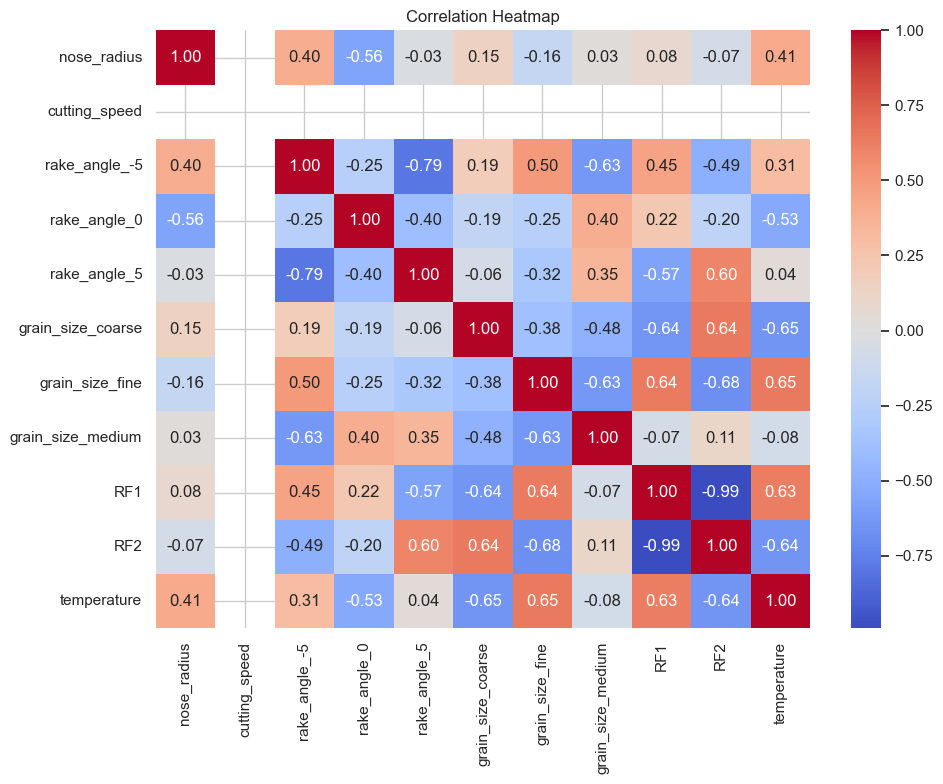

In [9]:
heatmap_df = pd.concat([X_encoded, y.reset_index(drop=True)], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

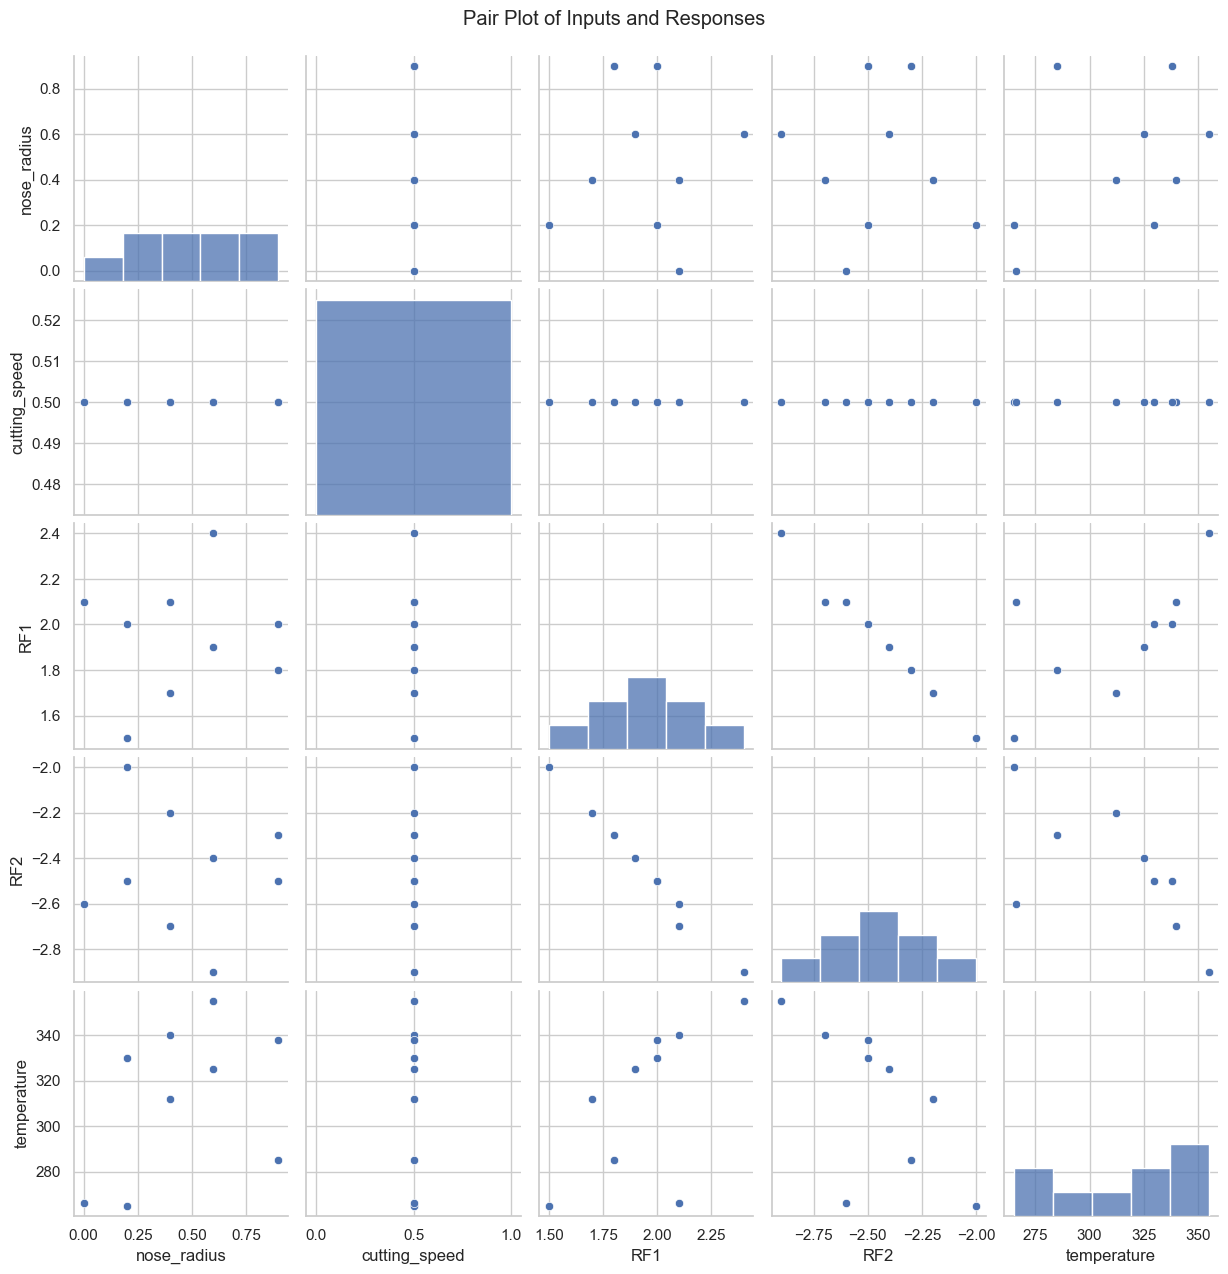

In [10]:
pair_plot_columns = ["rake_angle", "nose_radius", "cutting_speed", "RF1", "RF2", "temperature"]
pair_plot = sns.pairplot(df_clean[pair_plot_columns], diag_kind="hist")
pair_plot.fig.suptitle("Pair Plot of Inputs and Responses", y=1.02)
pair_plot.fig.savefig(PLOTS_DIR / "pair_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(pair_plot.fig)

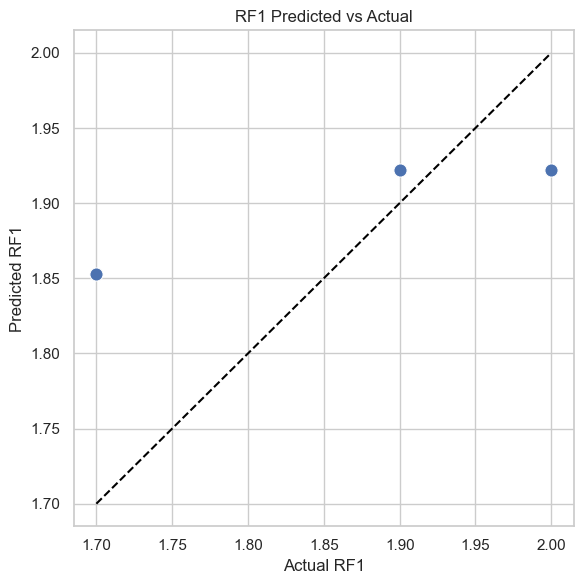

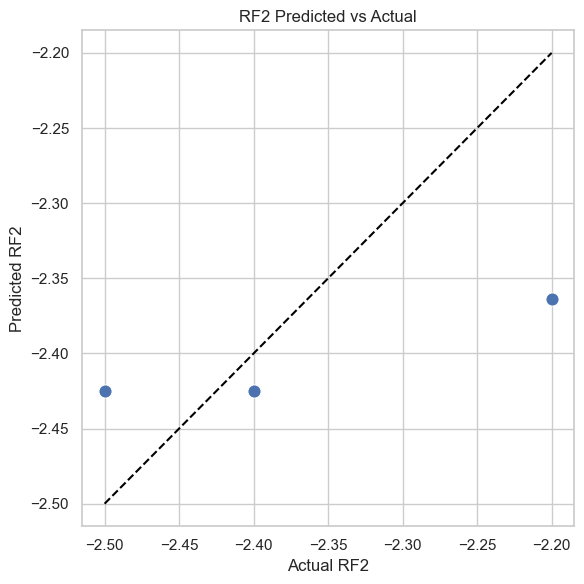

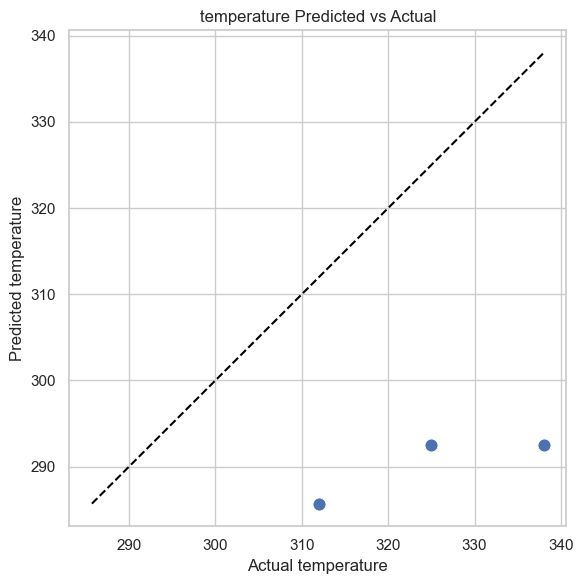

In [11]:
for index, target in enumerate(TARGET_COLUMNS):
    plt.figure(figsize=(6, 6))
    actual = y_test.iloc[:, index].to_numpy()
    predicted = y_test_pred[:, index]
    sns.scatterplot(x=actual, y=predicted, s=90)
    lower = min(actual.min(), predicted.min())
    upper = max(actual.max(), predicted.max())
    plt.plot([lower, upper], [lower, upper], linestyle="--", color="black")
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"{target} Predicted vs Actual")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{target.lower()}_prediction_vs_actual.png", dpi=300)
    plt.show()
    plt.close()

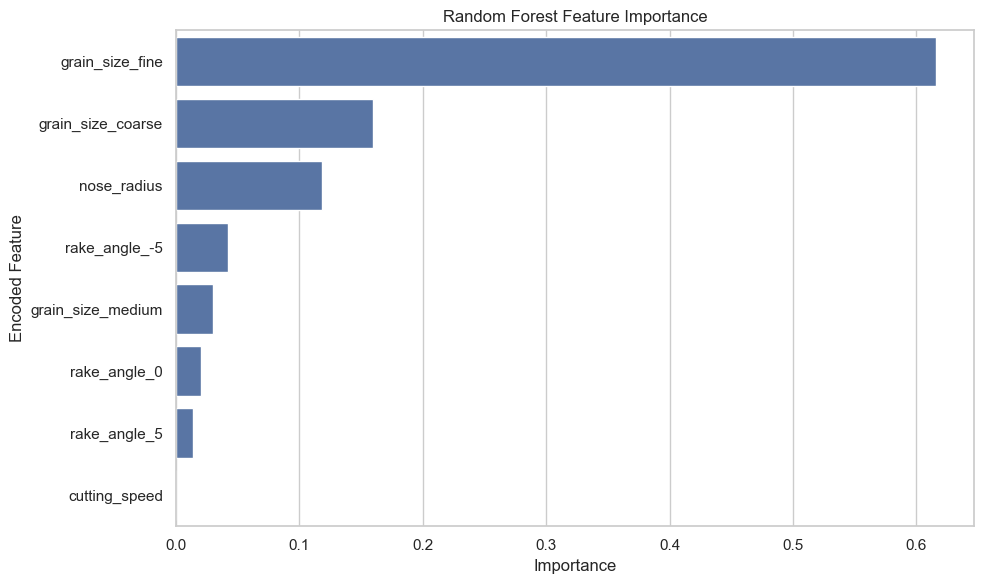

In [12]:
feature_importance = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, orient="h")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Encoded Feature")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance.png", dpi=300)
plt.show()
plt.close()

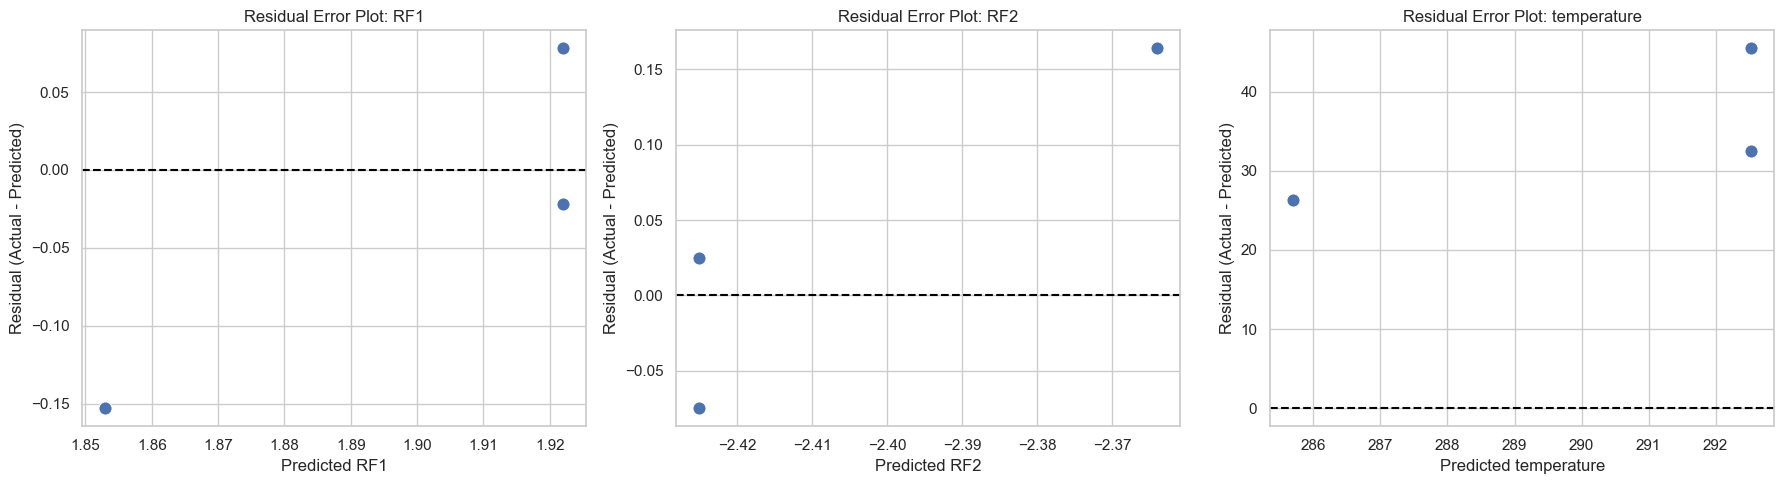

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for index, target in enumerate(TARGET_COLUMNS):
    actual = y_test.iloc[:, index].to_numpy()
    predicted = y_test_pred[:, index]
    residuals = actual - predicted
    sns.scatterplot(x=predicted, y=residuals, s=90, ax=axes[index])
    axes[index].axhline(0, linestyle="--", color="black")
    axes[index].set_title(f"Residual Error Plot: {target}")
    axes[index].set_xlabel(f"Predicted {target}")
    axes[index].set_ylabel("Residual (Actual - Predicted)")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "residual_error_plot.png", dpi=300)
plt.show()
plt.close(fig)

<h5>Prediction of Machining Responses</h5>

<small>This section estimates `RF1`, `RF2`, and temperature for a selected set of end-milling input conditions.</small>

In [14]:
def prepare_features(input_df, encoded_feature_names):
    candidate = input_df.copy()
    for column in CATEGORICAL_COLUMNS:
        candidate[column] = candidate[column].astype(str)
    encoded = pd.get_dummies(candidate, columns=CATEGORICAL_COLUMNS, dtype=float)
    return encoded.reindex(columns=encoded_feature_names, fill_value=0)


def predict_conditions(input_df):
    prepared_features = prepare_features(input_df[FEATURE_COLUMNS], feature_names)
    predictions = final_model.predict(prepared_features)
    prediction_df = pd.DataFrame(predictions, columns=TARGET_COLUMNS)
    return pd.concat([input_df.reset_index(drop=True), prediction_df], axis=1)

single_input = pd.DataFrame(
    [
        {
            "rake_angle": 5,
            "nose_radius": 1.0,
            "grain_size": "coarse",
            "cutting_speed": 0.5,
        }
    ]
)

single_prediction = predict_conditions(single_input)
print("Single prediction result:")
display(single_prediction)

Single prediction result:


,rake_angle,nose_radius,grain_size,cutting_speed,RF1,RF2,temperature
0,5,1.0,coarse,0.5,1.755,-2.256,283.66


<h5>Batch Prediction</h5>

<small>Multiple machining conditions can also be evaluated by reading `prediction_inputs.xlsx` and exporting the predicted responses to `predictions.xlsx`.</small>

In [15]:
if not BATCH_INPUT_PATH.exists():
    demo_batch_input = pd.DataFrame(
        [
            {"rake_angle": 5, "nose_radius": 1.0, "grain_size": "coarse", "cutting_speed": 0.5},
            {"rake_angle": -5, "nose_radius": 0.6, "grain_size": "fine", "cutting_speed": 0.5},
            {"rake_angle": 5, "nose_radius": 0.4, "grain_size": "medium", "cutting_speed": 0.5},
        ]
    )
    demo_batch_input.to_excel(BATCH_INPUT_PATH, index=False)
    print(f"Created demo batch-input file at: {BATCH_INPUT_PATH}")

batch_input_df = pd.read_excel(BATCH_INPUT_PATH)
missing_batch_columns = [column for column in FEATURE_COLUMNS if column not in batch_input_df.columns]
if missing_batch_columns:
    raise ValueError(f"Batch input file is missing required columns: {missing_batch_columns}")

batch_predictions = predict_conditions(batch_input_df[FEATURE_COLUMNS])
batch_predictions.to_excel(BATCH_OUTPUT_PATH, index=False)
print(f"Saved batch predictions to: {BATCH_OUTPUT_PATH}")
display(batch_predictions)

Saved batch predictions to: c:\Users\greyy\Documents\nimonic_ai\predictions.xlsx


,rake_angle,nose_radius,grain_size,cutting_speed,RF1,RF2,temperature
0,5,1.0,coarse,0.5,1.755,-2.256,283.66
1,-5,0.6,fine,0.5,2.302,-2.826,349.45
2,5,0.4,medium,0.5,1.853,-2.364,285.70


<h5>Engineering Discussion</h5>

<small>
- Grain size influences the mechanical response of the alloy and can affect both cutting force levels and thermal behaviour during machining.
- Nose radius changes the tool-workpiece interaction, which can alter `RF1`, `RF2`, and the generated temperature.
- Variations in `RF1` reflect changes in the main cutting force, while `RF2` captures changes in the thrust component.
- Temperature trends are important because they indicate the thermal load associated with the studied machining conditions.
- The predictive model is used here as a compact research tool for estimating machining responses within the studied parameter range.
</small>